# Import libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.ion()


import mne
mne.set_log_level('error')


import os
import random
import shutil

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.options.display.max_columns = None # показываем все колонки

In [2]:
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold,  cross_validate, LeaveOneGroupOut
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Load files

In [3]:
def load_epochs_to_numpy(file_path, groups=False):
    shutil.unpack_archive(file_path, extract_dir=os.path.dirname(file_path), format='zip')
    fif_path = os.path.splitext(file_path)[0] + '.fif'
    epochs = mne.read_epochs(fif_path, preload=True)
    os.remove(fif_path)

    # --- Визуализация событий ---
    fig, ax = plt.subplots(figsize=[15, 5])
    mne.viz.plot_events(
        epochs.events,
        epochs.info['sfreq'],
        event_id=epochs.event_id,
        axes=ax
    )
    plt.show()


    X = epochs.get_data(copy=False)        # (epochs, channels, time)
    y = epochs.events[:, 2]                # метки классов

    print(f'X: {X.shape} (эпохи, каналы, время)')
    print(f'y: {y.shape} (метки классов)')

    if groups:
        session_groups = epochs.metadata['session'].values
        subject_groups = epochs.metadata['subject'].values
        print(f'subject_groups: {subject_groups.shape} ')
        print(f'session_groups: {session_groups.shape} ')
        return X, y, subject_groups, session_groups
    else:
        return X, y

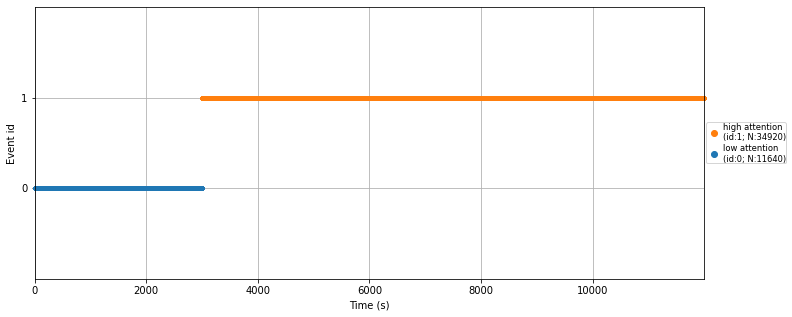

X: (46560, 12, 128) (эпохи, каналы, время)
y: (46560,) (метки классов)
subject_groups: (46560,) 
session_groups: (46560,) 


In [4]:
file_path = r'epochs\sam40_full_epochs.zip'
sam40_X, sam40_y, sam40_subjects, sam40_sessions  = load_epochs_to_numpy(file_path, groups=True)

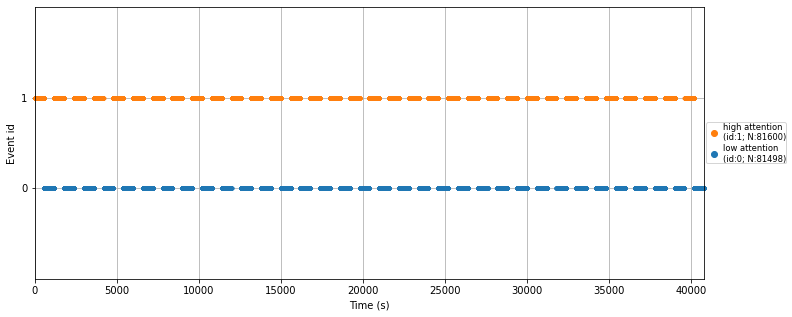

X: (163098, 12, 128) (эпохи, каналы, время)
y: (163098,) (метки классов)
subject_groups: (163098,) 
session_groups: (163098,) 


In [5]:
file_path = r'epochs\distinguishing_epochs.zip'
distinguish_X, distinguish_y, distinguish_subjects, distinguish_sessions = load_epochs_to_numpy(file_path, groups=True)

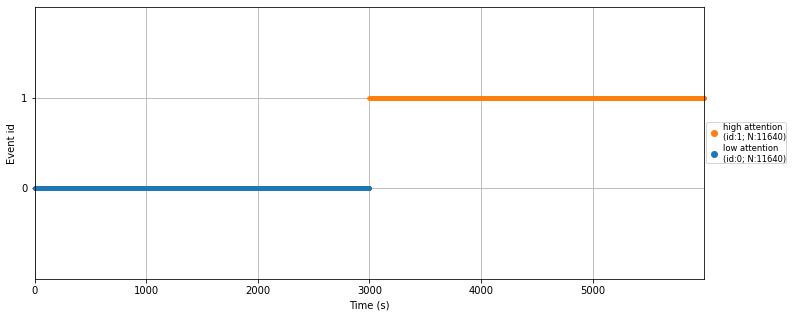

X: (23280, 12, 128) (эпохи, каналы, время)
y: (23280,) (метки классов)


In [6]:
file_path = r'epochs\sam40_stroop_epochs.zip'
stroop_X, stroop_y = load_epochs_to_numpy(file_path)

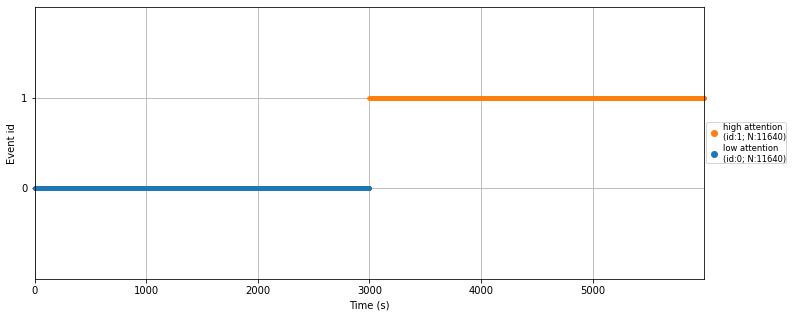

X: (23280, 12, 128) (эпохи, каналы, время)
y: (23280,) (метки классов)


In [7]:
file_path = r'epochs\sam40_arithmetic_epochs.zip'
arithmetic_X, arithmetic_y = load_epochs_to_numpy(file_path)

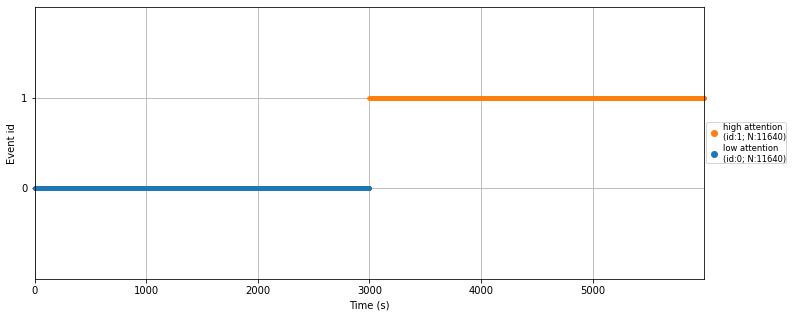

X: (23280, 12, 128) (эпохи, каналы, время)
y: (23280,) (метки классов)


In [8]:
file_path = r'epochs\sam40_mirror_epochs.zip'
mirror_X, mirror_y = load_epochs_to_numpy(file_path)

# Feature Extraction

## Basic feature engineering


In [9]:
from mne_features.feature_extraction import extract_features


def extract_basic_eeg_features(X, y, label):
    sfreq = 128
    freq_bands = [
        (0.5, 4),   # delta
        (4, 8),     # theta
        (8, 13),    # alpha
        (13, 30),   # beta
        (30, 45)    # gamma
    ]
    
    selected_features = [
        'pow_freq_bands',
        'higuchi_fd',
        'katz_fd'
    ]
    
    initial_shape = X.shape

    # Извлекаем признаки
    new_X = extract_features(
        X, sfreq=sfreq,
        selected_funcs=selected_features,
        funcs_params={
            'pow_freq_bands__freq_bands': freq_bands,
            'pow_freq_bands__log': True
        }
    )

    # Выводим информацию
    print(f'{label}:')
    print(f'  X исходная: {initial_shape} (эпохи, каналы, время)')
    print(f'  X после fe: {new_X.shape} (эпохи, признаки)')
    print(f'  y: {y.shape} (метки классов)')
    
    return new_X

## STFT

In [10]:
def extract_stft_features(X, y, label):
    
    # Параметры STFT
    n_epochs, n_channels, n_times = X.shape
    wsize = 128
    tstep = wsize // 4
    

    
    X_reshaped = X.reshape(n_epochs * n_channels, n_times)


    stft_result = np.abs(mne.time_frequency.stft(X_reshaped, wsize=wsize, tstep=tstep))
    _, n_freqs, n_t_new = stft_result.shape
    
    stft_4d = stft_result.reshape(n_epochs, n_channels, n_freqs, n_t_new)


    new_X = stft_4d.reshape(n_epochs, n_channels * n_freqs * n_t_new)


    # Вывод всех результатов
    print(f'{label}:')
    print(f'  X исходная: {X.shape} (эпохи, каналы, время)')
    print(f'  X reshape для STFT: {X_reshaped.shape} (сигналы, время)')
    print(f'  X после STFT: {stft_result.shape} (сигналы, частоты, временные шаги)')
    print(f'  X reshape после STFT: {stft_4d.shape } (эпохи, каналы, частоты, временные шаги)')
    print(f'  X reshape финальный: {new_X.shape} (эпохи, признаки)')
    print(f'  y: {y.shape} (метки классов)')
    
    return new_X

In [23]:
def extract_stft_band_features(X, y, label, sfreq=128):
    """
    Извлекает признаки STFT, усредняя мощность по заданным частотным диапазонам,
    но сохраняя временное разрешение.
    """
    # Частотные диапазоны
    freq_bands = {
        "delta": (0.5, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta": (13, 30),
        "gamma": (30, 45)
    }
    n_bands = len(freq_bands)

    # Параметры STFT
    n_epochs, n_channels, n_times = X.shape
    wsize = 128
    tstep = wsize // 4

    # Шаги 1-3: Вычисление STFT (как и раньше)
    X_reshaped = X.reshape(n_epochs * n_channels, n_times)
    stft_result = np.abs(mne.time_frequency.stft(X_reshaped, wsize=wsize, tstep=tstep))
    stft_4d = stft_result.reshape(n_epochs, n_channels, stft_result.shape[1], stft_result.shape[2])
    _, _, n_freqs, n_t_new = stft_4d.shape # (эпохи, каналы, частоты, время)

    # Шаг 4: Усреднение по частотным диапазонам
    # Получаем реальные частоты для каждого бина STFT
    freqs = mne.time_frequency.stftfreq(wsize=wsize, sfreq=sfreq)

    # Список для хранения усредненных по диапазонам данных
    band_features_list = []
    for fmin, fmax in freq_bands.values():
        # Находим индексы частот, попадающих в текущий диапазон
        freq_mask = (freqs >= fmin) & (freqs < fmax)
        # Усредняем по оси частот (axis=2), используя маску
        band_power = stft_4d[:, :, freq_mask, :].mean(axis=2)
        band_features_list.append(band_power)

    # Объединяем результаты по всем диапазонам в один массив
    # Новая форма будет (эпохи, каналы, диапазоны, время)
    band_features_4d = np.stack(band_features_list, axis=2)

    # Шаг 5: Финальное изменение формы для создания вектора признаков
    # Объединяем каналы, диапазоны и временные шаги
    new_X = band_features_4d.reshape(n_epochs, n_channels * n_bands * n_t_new)

    # Вывод результатов
    print(f'{label}:')
    print(f'  X исходная: {X.shape} (эпохи, каналы, время)')
    print(f'  X reshape для STFT: {X_reshaped.shape} (сигналы, время)')
    print(f'  X после STFT: {stft_result.shape} (сигналы, частоты, время)')
    print(f'  X reshape после STFT: {stft_4d.shape } (эпохи, каналы, частоты, время)')
    print(f'  X после усреднения по диапазонам: {band_features_4d.shape} (эпохи, каналы, диапазоны, время)')
    print(f'  X reshape финальный: {new_X.shape} (эпохи, признаки)')
    print(f'  y: {y.shape}')

    return new_X



## Process

In [ ]:
sam40_X = extract_basic_eeg_features(sam40_X, sam40_y,'SAM40')

In [12]:
stroop_X = extract_basic_eeg_features(stroop_X, stroop_y,'Stroop')

Stroop:
  X исходная: (23280, 12, 128) (эпохи, каналы, время)
  X после fe: (23280, 84) (эпохи, признаки)
  y: (23280,) (метки классов)


In [13]:
arithmetic_X = extract_basic_eeg_features(arithmetic_X, arithmetic_y,'Arithmetic')

Arithmetic:
  X исходная: (23280, 12, 128) (эпохи, каналы, время)
  X reshape для STFT: (279360, 128) (сигналы, время)
  X после STFT: (279360, 65, 4) (сигналы, частоты, временные шаги)
  X reshape после STFT: (23280, 12, 65, 4) (эпохи, каналы, частоты, временные шаги)
  X reshape финальный: (23280, 3120) (эпохи, признаки)
  y: (23280,) (метки классов)


In [24]:
mirror_X = extract_basic_eeg_features(mirror_X, mirror_y,'Mirror')

Mirror:
  X исходная: (23280, 12, 128) (эпохи, каналы, время)
  X reshape для STFT: (279360, 128) (сигналы, время)
  X после STFT: (279360, 65, 4) (сигналы, частоты, время)
  X reshape после STFT: (23280, 12, 65, 4) (эпохи, каналы, частоты, время)
  X после усреднения по диапазонам: (23280, 12, 5, 4) (эпохи, каналы, диапазоны, время)
  X reshape финальный: (23280, 240) (эпохи, признаки)
  y: (23280,)


In [ ]:
distinguish_X = extract_basic_eeg_features(distinguish_X, distinguish_y,'Distinguishing')

# Table, Model, Functions

In [ ]:
column_names = ['scenario','accuracy', 'precision', 'recall', 'f1']

table = pd.DataFrame({col: pd.Series(dtype='object') for col in column_names})



In [ ]:
xgb_classifier = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=7,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Accuracy = 0.76
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 700, 'subsample': 0.8}

In [ ]:
def add_to_table(table, results, scenario):
    new_row = pd.DataFrame([{'scenario': scenario, **results.loc['mean'].to_dict()}])
    return pd.concat([table, new_row], ignore_index=True)

In [ ]:
def run_transfer(X_train, y_train, X_test, y_test, label):
    # пересоздаем пайплайн при каждом запуске
    fresh_classifier = clone(xgb_classifier)

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', fresh_classifier)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1': f1_score(y_test, y_pred, average='weighted')
    }

    return pd.DataFrame([{'scenario': label, **metrics}]).round(2)

In [ ]:
def evaluate_cv(X, y, cv):
    
    # пересоздаем пайплайн при каждом запуске
    fresh_classifier = clone(xgb_classifier)

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', fresh_classifier)
    ])
    
    # --- метрики ---
    scoring = {
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'f1': make_scorer(f1_score)
    }

    # --- кросс-валидация ---
    cv_results = cross_validate(
        pipeline, X, y,
        cv=cv,
        scoring=scoring
    )

    # --- таблица результатов ---
    metrics_table = pd.DataFrame({
        metric: cv_results[f'test_{metric}'] for metric in scoring.keys()
    })
    metrics_table.loc['mean'] = metrics_table.mean()
    return metrics_table.round(2)

# Baselines

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = evaluate_cv(distinguish_X, distinguish_y, skf)
table = add_to_table(table, results, scenario='Baseline: Distinguishing')
results 

,accuracy,precision,recall,f1
0,0.74,0.75,0.73,0.74
1,0.75,0.75,0.74,0.75
2,0.75,0.75,0.74,0.75
3,0.75,0.75,0.74,0.74
4,0.75,0.75,0.75,0.75
mean,0.75,0.75,0.74,0.74


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = evaluate_cv(sam40_X, sam40_y, skf)
table = add_to_table(table, results, scenario='Baseline: SAM40')
results 

,accuracy,precision,recall,f1
0,0.77,0.78,0.96,0.86
1,0.77,0.79,0.96,0.86
2,0.77,0.79,0.96,0.86
3,0.77,0.78,0.96,0.86
4,0.78,0.79,0.96,0.87
mean,0.77,0.79,0.96,0.86


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = evaluate_cv(stroop_X, stroop_y, skf)
table = add_to_table(table, results, scenario='Baseline: Stroop')
results 

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = evaluate_cv(arithmetic_X, arithmetic_y, skf)
table = add_to_table(table, results, scenario='Baseline: Arithmetic')
results 

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = evaluate_cv(mirror_X, mirror_y, skf)
table = add_to_table(table, results, scenario='Baseline: Mirror')
results 

# Cross-Subjects

In [ ]:
logo = LeaveOneGroupOut()

cv = logo.split(distinguish_X, distinguish_y, groups=distinguish_subjects)
results = evaluate_cv(distinguish_X, distinguish_y, cv)
table = add_to_table(table, results, scenario='Cross-Subject: Distinguishing')
results 

,accuracy,precision,recall,f1
0,0.54,0.53,0.61,0.57
1,0.55,0.55,0.56,0.56
2,0.63,0.60,0.76,0.67
3,0.57,0.60,0.42,0.49
4,0.57,0.56,0.66,0.61
mean,0.57,0.57,0.60,0.58


In [ ]:
logo = LeaveOneGroupOut()

cv = logo.split(sam40_X, sam40_y, groups=sam40_subjects)
results = evaluate_cv(sam40_X, sam40_y, cv)
table = add_to_table(table, results, scenario='Cross-Subject: SAM40')
results 

,accuracy,precision,recall,f1
0,0.73,0.78,0.89,0.83
1,0.77,0.77,0.98,0.86
2,0.70,0.75,0.92,0.82
3,0.73,0.75,0.95,0.84
4,0.73,0.76,0.92,0.83
5,0.66,0.76,0.79,0.77
6,0.77,0.79,0.95,0.86
7,0.68,0.75,0.86,0.80
8,0.73,0.77,0.92,0.84
9,0.68,0.76,0.85,0.80


# Cross-session

In [ ]:
logo = LeaveOneGroupOut()


cv = logo.split(distinguish_X, distinguish_y, groups=distinguish_sessions)
results = evaluate_cv(distinguish_X, distinguish_y, cv)
table = add_to_table(table, results, scenario='Cross-Session: Distinguishing')
results 

,accuracy,precision,recall,f1
0,0.55,0.55,0.64,0.59
1,0.56,0.55,0.62,0.58
2,0.58,0.57,0.66,0.61
3,0.60,0.61,0.53,0.57
4,0.58,0.59,0.55,0.57
5,0.54,0.53,0.74,0.62
6,0.61,0.59,0.70,0.64
mean,0.58,0.57,0.63,0.60


In [ ]:
logo = LeaveOneGroupOut()

cv = logo.split(sam40_X, sam40_y, groups=sam40_sessions)
results = evaluate_cv(sam40_X, sam40_y, cv)
table = add_to_table(table, results, scenario='Cross-Session: SAM40')
results 

,accuracy,precision,recall,f1
0,0.73,0.76,0.92,0.83
1,0.75,0.77,0.95,0.85
2,0.74,0.77,0.94,0.85
mean,0.74,0.77,0.94,0.84


# Cross-task + Cross-datasets

In [ ]:
scenarios = [
    # Cross-task внутри SAM40
    (stroop_X, stroop_y, arithmetic_X, arithmetic_y, 'Task: Stroop → Arithmetic'),
    (stroop_X, stroop_y, mirror_X, mirror_y, 'Task: Stroop → Mirror'),
    (arithmetic_X, arithmetic_y, stroop_X, stroop_y, 'Task: Arithmetic → Stroop'),
    (arithmetic_X, arithmetic_y, mirror_X, mirror_y, 'Task: Arithmetic → Mirror'),
    (mirror_X, mirror_y, stroop_X, stroop_y, 'Task: Mirror → Stroop'),
    (mirror_X, mirror_y, arithmetic_X, arithmetic_y, 'Task: Mirror → Arithmetic'),

    # Cross-dataset: SAM40 ↔ Distinguishing
    (distinguish_X, distinguish_y, sam40_X, sam40_y, 'Dataset: Distinguishing → SAM40'),
    (sam40_X, sam40_y, distinguish_X, distinguish_y, 'Dataset: SAM40 → Distinguishing'),

    # Cross-dataset: Distinguishing → SAM40 subtasks
    (distinguish_X, distinguish_y, stroop_X, stroop_y, 'Dataset: Distinguishing → Stroop'),
    (distinguish_X, distinguish_y, arithmetic_X, arithmetic_y, 'Dataset: Distinguishing → Arithmetic'),
    (distinguish_X, distinguish_y, mirror_X, mirror_y, 'Dataset: Distinguishing → Mirror'),

    # Cross-dataset: SAM40 subtasks → Distinguishing
    (stroop_X, stroop_y, distinguish_X, distinguish_y, 'Dataset: Stroop → Distinguishing'),
    (arithmetic_X, arithmetic_y, distinguish_X, distinguish_y, 'Dataset: Arithmetic → Distinguishing'),
    (mirror_X, mirror_y, distinguish_X, distinguish_y, 'Dataset: Mirror → Distinguishing'),
]



for X_src, y_src, X_tgt, y_tgt, label in scenarios:
    results = run_transfer(X_src, y_src, X_tgt, y_tgt, label)
    table = pd.concat([table, results], ignore_index=True)


table

In [ ]:
table[['scenario', 'data']] = table['scenario'].str.split(': ', n=1, expand=True)

# Жай

In [ ]:
# import numpy as np
# import mne

# # ----------------------------------------------------------------------
# # 1. Ваши данные (замените на свои реальные данные)
# # ----------------------------------------------------------------------
# n_epochs = 4608
# n_channels = 12
# n_times = 129
# sfreq = 128  # Ваша частота дискретизации (например, 128 Гц)

# X = np.random.randn(n_epochs, n_channels, n_times)
# y = np.random.randint(0, 2, n_epochs)

# # ----------------------------------------------------------------------
# # 2. Создание объекта MNE Info (метаданные)
# # ----------------------------------------------------------------------
# ch_names = [f'EEG {i+1}' for i in range(n_channels)]
# ch_types = ['eeg'] * n_channels

# info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)

# # ----------------------------------------------------------------------
# # 3. Создание объекта EpochsArray из ваших данных
# # ----------------------------------------------------------------------
# epochs = mne.EpochsArray(X, info, verbose=False)

# # ----------------------------------------------------------------------
# # 4. Вычисление PSD с использованием метода .compute_psd()
# # ----------------------------------------------------------------------
# # Задаем диапазон частот
# fmin = 0.5
# fmax = 30.0

# # Вычисляем PSD (Power Spectral Density)
# spectrum = epochs.compute_psd(method='welch', fmin=fmin, fmax=fmax, verbose=False)

# # Извлекаем данные и частоты из объекта Spectrum
# psds = spectrum.get_data()  # Это и есть ваши новые признаки
# freqs = spectrum.freqs

# # ----------------------------------------------------------------------
# # 5. Подготовка признаков для модели машинного обучения
# # ----------------------------------------------------------------------
# # 'psds' сейчас имеет форму (эпохи, каналы, частоты)
# # Мы 'выпрямляем' его в 2D массив (эпохи, признаки)
# n_epochs, n_channels, n_freqs = psds.shape
# X_psd_features = psds.reshape(n_epochs, n_channels * n_freqs)

# # ----------------------------------------------------------------------
# # 6. Проверка и вывод результатов
# # ----------------------------------------------------------------------
# print('Форма исходных данных X:', X.shape)
# print('='*40)
# print('Форма вычисленных PSD признаков (3D):', psds.shape)
# print('Количество частот:', len(freqs))
# print('='*40)
# print('Финальная форма признаков для модели (2D):', X_psd_features.shape)
# print('Метки 'y' по-прежнему соответствуют данным:', y.shape[0] == X_psd_features.shape[0])

# # Теперь вы можете использовать 'X_psd_features' и 'y' для обучения вашей модели.